In [36]:
import pandas as pd
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

# Loading dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Checking shape
print(df.shape)
df.head()


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\shahj\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [37]:
# 1. Data types and presence of NAs
df.info()

# 2. Number of NAs per column
print(df.isnull().sum())

# 3. Statistics
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free su

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [38]:
# Binary classification
df['target'] = (df['quality'] >= 6).astype(int)

# Verify classification
print(df['target'].value_counts())

target
1    855
0    744
Name: count, dtype: int64


In [39]:
# Definition of features (X) and label (y)
X = df.drop(columns=['quality', 'target'])
y = df['target']

In [40]:
from sklearn.model_selection import train_test_split

# Splitting 80% Train / 20% Test
# random_state=42 to have the same splitting everytime
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training size : {X_train.shape}")
print(f"Test size : {X_test.shape}")

Training size : (1279, 11)
Test size : (320, 11)


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. LOGISTIC REGRESSION

print("LOGISTIC REGRESSION")
# max_iter=1000 (to ensure convergence)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Prediction on test dataset
y_pred_log = log_reg.predict(X_test)

# Show evaluation metrics
print(classification_report(y_test, y_pred_log))
print("-" * 40)


# 2. DECISION TREE

print("\nDECISION TREE")
# random_state (to ensure reproduceability of the tree structure)
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)

# Prediction on test dataset
y_pred_tree = dec_tree.predict(X_test)

# Show evaluation metrics
print(classification_report(y_test, y_pred_tree))
print("-" * 40)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.72      0.76      0.74       149
           1       0.78      0.75      0.76       171

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320

----------------------------------------

DECISION TREE
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       149
           1       0.76      0.78      0.77       171

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320

----------------------------------------


In [42]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Cross-Validation for Logistic Regression
log_reg_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), X, y, cv=5, scoring='f1')

print("CROSS-VALIDATION : LOGISTIC REGRESSION")
print(f"5-fold scores : {log_reg_cv}")
print(f"F1-scores mean : {log_reg_cv.mean():.3f}")
print(f"Variance : {log_reg_cv.std():.3f}")
print("-" * 45)

# 2. Cross-Validation for Decision Tree
tree_cv = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=5, scoring='f1')

print("\nCROSS-VALIDATION : DECISION TREE")
print(f"5-fold scores : {tree_cv}")
print(f"F1-scores mean : {tree_cv.mean():.3f}")
print(f"Variance : {tree_cv.std():.3f}")
print("-" * 45)

CROSS-VALIDATION : LOGISTIC REGRESSION
5-fold scores : [0.65734266 0.71764706 0.78235294 0.78421053 0.77011494]
F1-scores mean : 0.742
Variance : 0.049
---------------------------------------------

CROSS-VALIDATION : DECISION TREE
5-fold scores : [0.5915493  0.66292135 0.71216617 0.74603175 0.54258675]
F1-scores mean : 0.651
Variance : 0.075
---------------------------------------------


In [43]:
from sklearn.metrics import classification_report

# 1. Probability of being a "good wine" (class 1)
# .predict_proba() returns [probability_class_0, probability_class_1]
y_probabilities = log_reg.predict_proba(X_test)[:, 1]

# 2. Testing different thresholds
thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    print(f"Threshold : {t}")

    # Si la probabilité est >= t, on prédit 1, sinon 0
    y_pred_custom = (y_probabilities >= t).astype(int)

    # Affichage du rapport de classification
    print(classification_report(y_test, y_pred_custom, target_names=['Poor (0)', 'Good (1)']))

Threshold : 0.3
              precision    recall  f1-score   support

    Poor (0)       0.80      0.47      0.59       149
    Good (1)       0.66      0.90      0.76       171

    accuracy                           0.70       320
   macro avg       0.73      0.69      0.68       320
weighted avg       0.73      0.70      0.68       320

Threshold : 0.5
              precision    recall  f1-score   support

    Poor (0)       0.72      0.76      0.74       149
    Good (1)       0.78      0.75      0.76       171

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320

Threshold : 0.7
              precision    recall  f1-score   support

    Poor (0)       0.63      0.90      0.74       149
    Good (1)       0.86      0.54      0.66       171

    accuracy                           0.71       320
   macro avg       0.74      0.72      0.70       320
weighted avg       0.75   

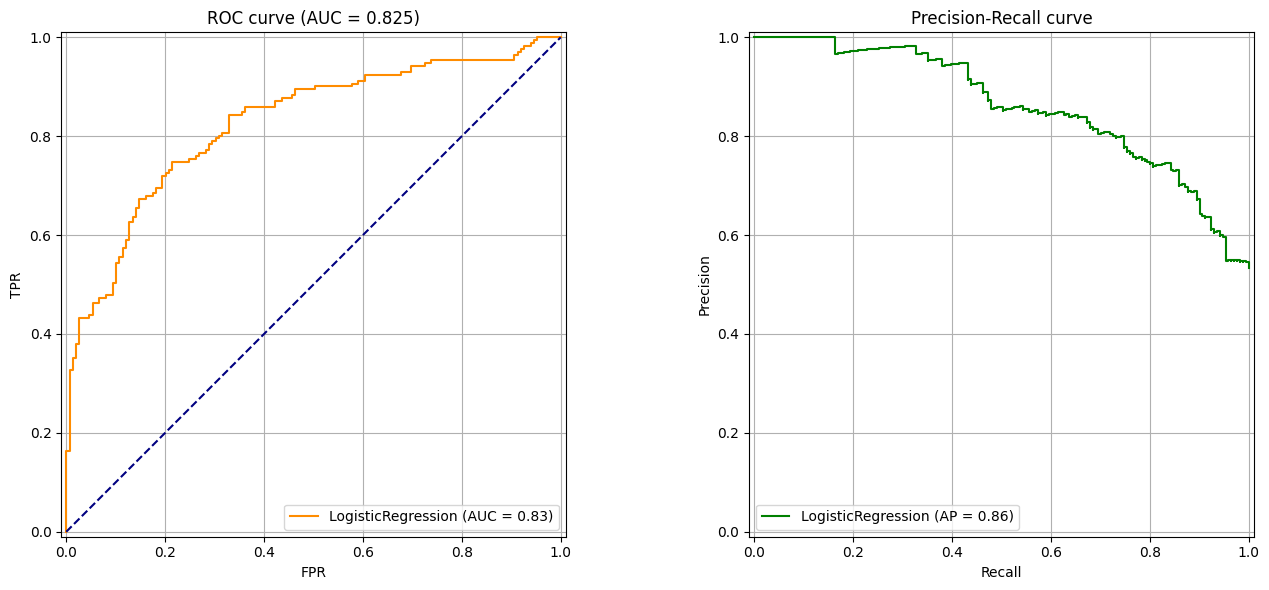

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score

# 1. Calculate AUC (Area Under the Curve)
y_probabilities = log_reg.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probabilities)

# 2. Configuration of the drawing area (2 graphs side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Graph 1 : ROC curve
RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=ax1, color="darkorange")
ax1.plot([0, 1], [0, 1], color="navy", linestyle="--")  # random reference line
ax1.set_title(f"ROC curve (AUC = {auc_score:.3f})")
ax1.set_xlabel("FPR")
ax1.set_ylabel("TPR")
ax1.grid(True)

# Graph 2 : Precision-Recall curve
PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test, ax=ax2, color="green")
ax2.set_title("Precision-Recall curve")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.grid(True)

plt.tight_layout()
plt.show()

SUCCESS: file saved as 'model_comparison.png'


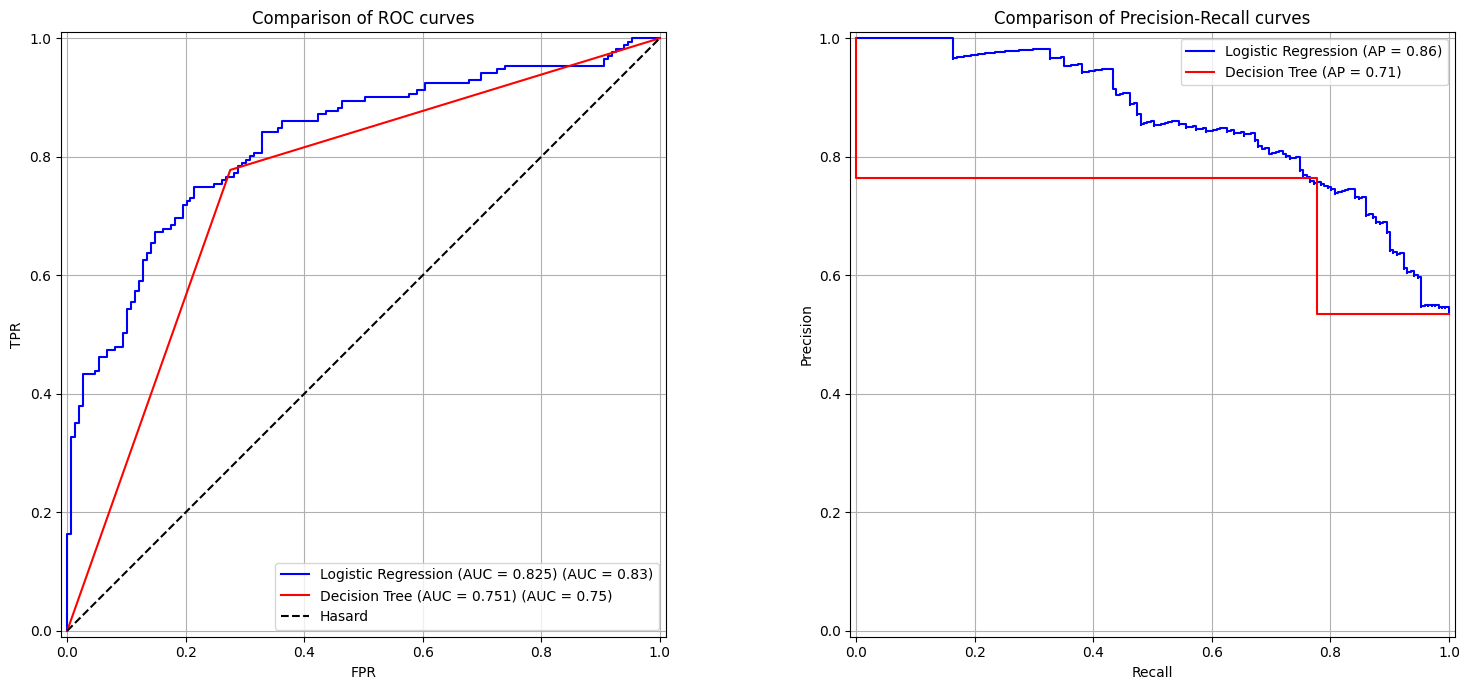

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score

# 1. Calculate probabilities for both models
log_reg_probs = log_reg.predict_proba(X_test)[:, 1]
dec_tree_probs = dec_tree.predict_proba(X_test)[:, 1]

# 2. Calculate AUC scores
log_reg_auc = roc_auc_score(y_test, log_reg_probs)
dec_tree_auc = roc_auc_score(y_test, dec_tree_probs)

# 3. Configuration of the drawing area (2 graphs)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Graph 1 : Comparison of ROC curves
RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=ax1, color="blue", name=f"Logistic Regression (AUC = {log_reg_auc:.3f})")
RocCurveDisplay.from_estimator(dec_tree, X_test, y_test, ax=ax1, color="red", name=f"Decision Tree (AUC = {dec_tree_auc:.3f})")
ax1.plot([0, 1], [0, 1], color="black", linestyle="--", label="Random")
ax1.set_title("Comparison of ROC curves")
ax1.set_xlabel("FPR")
ax1.set_ylabel("TPR")
ax1.legend()
ax1.grid(True)

# Graph 2 : Comparison of Precision-Recall curves
PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test, ax=ax2, color="blue", name="Logistic Regression")
PrecisionRecallDisplay.from_estimator(dec_tree, X_test, y_test, ax=ax2, color="red", name="Decision Tree")
ax2.set_title("Comparison of Precision-Recall curves")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
# Save file as png
plt.savefig("model_comparison.png", dpi=300)
print("SUCCESS: file saved as 'model_comparison.png'")
plt.show()